In [ ]:
pip install pandas scikit-learn matplotlib seaborn

# 1. Data Loading and Initial Exploration

Load data and perform initial inspections. Examine missing values and the distribution of the 'Sleep Disorder' column.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(df.head())

print("Target Distribution:")
target = df['Sleep Disorder'].fillna('None').value_counts().reset_index()
target.columns = ['Sleep Disorder', 'Count']
target['Percentage'] = (target['Count'] / len(df) * 100).round(2).astype(str) + '%'
display(target)

print("Dataset Info:")
display(pd.DataFrame({
    'Column': df.columns,
    'Type': df.dtypes.values,
    'Missing': df.isnull().sum().values,
    'Unique': df.nunique().values
}))

Dataset loaded: 374 rows, 13 columns



,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


Target Distribution:


,Sleep Disorder,Count,Percentage
0,None,219,58.56%
1,Sleep Apnea,78,20.86%
2,Insomnia,77,20.59%


Dataset Info:


,Column,Type,Missing,Unique
0,Person ID,int64,0,374
1,Gender,object,0,2
2,Age,int64,0,31
3,Occupation,object,0,11
4,Sleep Duration,float64,0,27
5,Quality of Sleep,int64,0,6
6,Physical Activity Level,int64,0,16
7,Stress Level,int64,0,6
8,BMI Category,object,0,4
9,Blood Pressure,object,0,25


# 2. Data Cleaning and Preprocessing

Data cleaning involves removing 'Person ID', separating 'Blood Pressure' components, handling missing 'Sleep Disorder' entries, and encoding categorical attributes.

In [ ]:
df_clean = df.copy()
df_clean = df_clean.drop('Person ID', axis=1)

df_clean[['Systolic', 'Diastolic']] = (df_clean['Blood Pressure'].str.split('/', expand=True).astype(int))
df_clean = df_clean.drop('Blood Pressure', axis=1)
# Fill missing
df_clean['Sleep Disorder'] = df_clean['Sleep Disorder'].fillna('None')
# Encode categorical
le_dict = {}
encoding_records = []
for col in ['Gender', 'Occupation', 'BMI Category']:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    le_dict[col] = le
    for orig, enc in zip(le.classes_, le.transform(le.classes_)):
        encoding_records.append({'Column': col, 'Original': orig, 'Encoded': enc})

# Encode target
le_target = LabelEncoder()
df_clean['Sleep Disorder'] = le_target.fit_transform(df_clean['Sleep Disorder'])
target_map = pd.DataFrame({
    'Original Label': le_target.classes_,
    'Encoded Value': le_target.transform(le_target.classes_)
})
print("\n Target Encoding:")
display(target_map)

print("\n Cleaned Dataset (first 5 rows):")
display(df_clean.head())


 Cleaned Dataset (first 5 rows):


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,27,9,6.1,6,42,6,3,77,4200,1,126,83
1,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
2,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
3,1,28,6,5.9,4,30,8,2,85,3000,2,140,90
4,1,28,6,5.9,4,30,8,2,85,3000,2,140,90


# 3. Data Splitting

Divide data into 80/20 train/test sets, ensuring 'Sleep Disorder' distribution is preserved via stratification.

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clean.drop('Sleep Disorder', axis=1)
y = df_clean['Sleep Disorder']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

split_df = pd.DataFrame({
    'Set': ['Train', 'Test', 'Total'],
    'Rows': [len(X_train_raw), len(X_test_raw), len(X)],
    'Percentage': ['80%', '20%', '100%'],
    'None': [
        sum(y_train == 0), sum(y_test == 0), sum(y == 0)
    ],
    'Insomnia': [
        sum(y_train == 1), sum(y_test == 1), sum(y == 1)
    ],
    'Sleep Apnea': [
        sum(y_train == 2), sum(y_test == 2), sum(y == 2)
    ],
})
display(split_df)

,Set,Rows,Percentage,None,Insomnia,Sleep Apnea
0,Train,299,80%,62,175,62
1,Test,75,20%,15,44,16
2,Total,374,100%,77,219,78


# 4. Feature Importance Analysis

Identify key features influencing sleep disorder prediction using RandomForest. Eliminate less impactful features for model efficiency.

📊 Feature Importance Ranking (from Train set only):


,Feature,Importance Score,Status
1,BMI Category,0.1808,✅ Keep
2,Occupation,0.1554,✅ Keep
3,Systolic,0.1454,✅ Keep
4,Diastolic,0.1138,✅ Keep
5,Age,0.1093,✅ Keep
6,Sleep Duration,0.1002,✅ Keep
7,Physical Activity Level,0.0679,✅ Keep
8,Daily Steps,0.0466,✅ Keep
9,Heart Rate,0.0403,✅ Keep
10,Stress Level,0.0180,✅ Keep


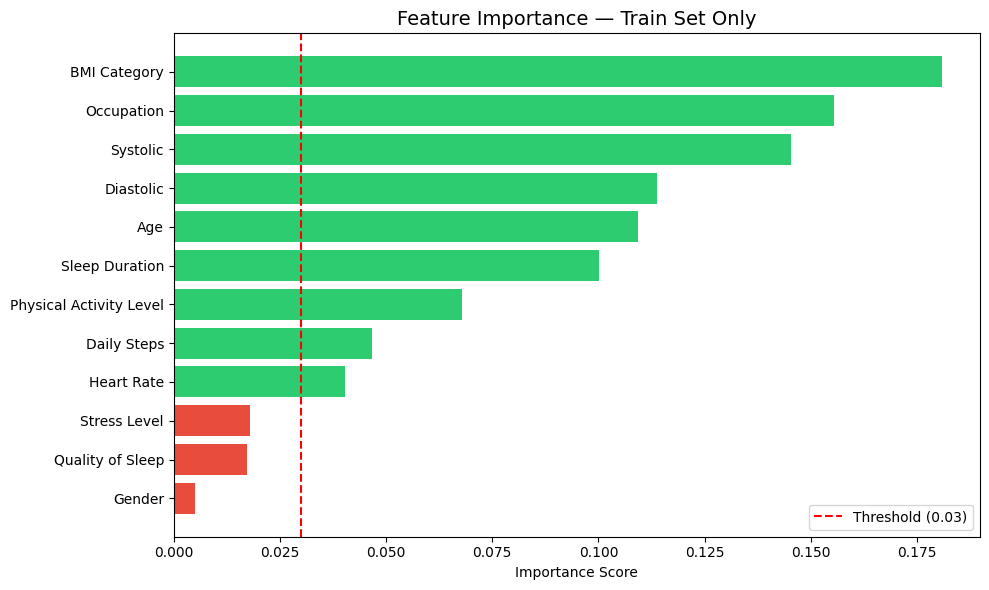


✅ Selected 11 features: ['BMI Category', 'Occupation', 'Systolic', 'Diastolic', 'Age', 'Sleep Duration', 'Physical Activity Level', 'Daily Steps', 'Heart Rate', 'Stress Level', 'Quality of Sleep']


In [ ]:
rf_importance = RandomForestClassifier(n_estimators=100, random_state=42)
rf_importance.fit(X_train, y_train)  #Train only

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance Score': rf_importance.feature_importances_.round(4),
}).sort_values('Importance Score', ascending=False).reset_index(drop=True)

importance_df.index += 1
importance_df['Status'] = importance_df['Importance Score'].apply(
    lambda x: 'Keep' if x >= 0.01 else 'Remove'
)

print("Feature Importance Ranking (from Train set only):")
display(importance_df)

# Plot
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if v >= 0.02 else '#e74c3c'
          for v in importance_df['Importance Score']]
plt.barh(importance_df['Feature'][::-1],
         importance_df['Importance Score'][::-1],
         color=colors[::-1])
plt.axvline(x=0.03, color='red', linestyle='--', label='Threshold (0.03)')
plt.title('Feature Importance — Train Set Only', fontsize=14)
plt.xlabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.show()

# Select features
selected = importance_df[
    importance_df['Status'] == 'Keep'
]['Feature'].tolist()

X_train_sel = X_train[selected]
X_test_sel  = X_test[selected]   #apply same selection to test

print(f"\nSelected {len(selected)} features: {selected}")

# 5. Model Training and Hyperparameter Tuning

In [ ]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    rf_base, X_train_sel, y_train, cv=skf, scoring='accuracy'
)

cv_df = pd.DataFrame({
    'Fold': [f'Fold {i}' for i in range(1, 11)],
    'Accuracy': (cv_scores * 100).round(2),
    'Result': ['Good' if s*100 >= 85 else 'OK'
               if s*100 >= 75 else 'Low' for s in cv_scores]
})
print("10-Fold Cross Validation (Train set only):")
display(cv_df)

summary_df = pd.DataFrame({
    'Metric': ['Mean Accuracy', 'Std Deviation', 'Min', 'Max'],
    'Value': [
        f"{cv_scores.mean()*100:.2f}%",
        f"±{cv_scores.std()*100:.2f}%",
        f"{cv_scores.min()*100:.2f}%",
        f"{cv_scores.max()*100:.2f}%"
    ]
})
print("\nSummary:")
display(summary_df)

10-Fold Cross Validation (Train set only):


,Fold,Accuracy,Result
0,Fold 1,83.33,OK
1,Fold 2,80.00,OK
2,Fold 3,93.33,Good
3,Fold 4,90.00,Good
4,Fold 5,90.00,Good
5,Fold 6,86.67,Good
6,Fold 7,96.67,Good
7,Fold 8,86.67,Good
8,Fold 9,86.67,Good
9,Fold 10,89.66,Good



Summary:


,Metric,Value
0,Mean Accuracy,88.30%
1,Std Deviation,±4.52%
2,Min,80.00%
3,Max,96.67%


Train a RandomForest model. Utilize cross-validation for performance assessment and `GridSearchCV` for hyperparameter optimization to achieve maximum accuracy.

In [ ]:
param_grid = {
    'n_estimators'    : [50, 100, 200],
    'max_depth'       : [5, 10, 15],
    'min_samples_leaf': [1, 3, 5]
}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

# fit บน Train เท่านั้น
grid_search.fit(X_train_sel, y_train)

best_df = pd.DataFrame({
    'Parameter': list(grid_search.best_params_.keys()),
    'Best Value': list(grid_search.best_params_.values())
})
print("\nBest Parameters :")
display(best_df)

results = pd.DataFrame(grid_search.cv_results_)
top5 = results.nlargest(5, 'mean_test_score')[[
    'param_n_estimators', 'param_max_depth',
    'param_min_samples_leaf', 'mean_test_score', 'std_test_score'
]].copy()
top5.columns = ['Trees', 'Max Depth', 'Min Leaf', 'CV Accuracy', 'Std']
top5['CV Accuracy'] = (top5['CV Accuracy'] * 100).round(2).astype(str) + '%'
top5['Std'] = '±' + (top5['Std'] * 100).round(2).astype(str) + '%'
top5 = top5.reset_index(drop=True)
top5.index += 1

print(f"\nBest CV Accuracy: {grid_search.best_score_*100:.2f}%")
print("\nTop 5 Combinations:")
display(top5)


Best Parameters :


,Parameter,Best Value
0,max_depth,5
1,min_samples_leaf,1
2,n_estimators,50



Best CV Accuracy: 89.63%

Top 5 Combinations:


,Trees,Max Depth,Min Leaf,CV Accuracy,Std
1,50,5,1,89.63%,±3.48%
2,200,5,1,89.63%,±3.48%
3,50,10,3,89.63%,±2.33%
4,100,5,1,89.3%,±2.9%
5,50,5,3,89.3%,±2.49%


Evaluate model performance on test data. Review accuracy, classification report, and confusion matrix for comprehensive assessment.

# 6. Model Evaluation

Final Test Accuracy: 96.00%
Classification Report:


,precision,recall,f1-score,support
Insomnia,0.93,0.87,0.90,15.00
None,1.00,1.00,1.00,44.00
Sleep Apnea,0.88,0.94,0.91,16.00
accuracy,0.96,0.96,0.96,0.96
macro avg,0.94,0.93,0.94,75.00
weighted avg,0.96,0.96,0.96,75.00


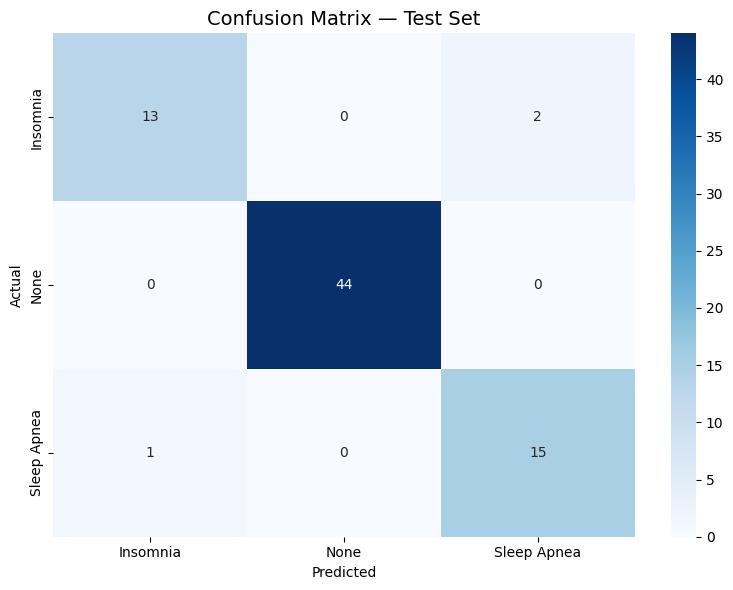

In [ ]:
best_model = grid_search.best_estimator_
best_model.fit(X_train_sel, y_train)

# Test set
y_pred = best_model.predict(X_test_sel)
accuracy = accuracy_score(y_test, y_pred)

print(f"Final Test Accuracy: {accuracy*100:.2f}%")

report = classification_report(
    y_test, y_pred,
    target_names=le_target.classes_,
    output_dict=True
)
report_df = pd.DataFrame(report).T.round(2)
print("Classification Report:")
display(report_df)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix — Test Set', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()